In [2]:
#1.导入库和设置中文防止乱码
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import rcParams

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#2.读取清洗好的数据
df = pd.read_csv('../data/clean_data.csv',parse_dates=['order_purchase_timestamp']) #parse_dates=['order_purchase_timestamp']:把订单时间变成真正的时间格式（方便后面算月份差）

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_unique_id        112650 non-null  object        
 1   order_id                  112650 non-null  object        
 2   order_purchase_timestamp  112650 non-null  datetime64[ns]
 3   price                     112650 non-null  float64       
 4   product_id                112650 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 4.3+ MB


### Cohort Analysis

In [6]:
#1.找到每个用户第一次购买的时间
#按照ID分组，取最早的订单时间
cohort_users = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()

#改列名：第一次购买时间
cohort_users.rename(columns={'order_purchase_timestamp':'first_order_time'},inplace=True)

In [7]:
#2.将第一次购买时间合并回原表
df = df.merge(cohort_users,on='customer_unique_id',how='left')

In [8]:
df.head()

,customer_unique_id,order_id,order_purchase_timestamp,price,product_id,first_order_time
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,87285b34884572647811a353c7ac498a,2017-09-04 11:26:38
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70,595fac2a385ac33a80bd5114aec74eb8,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90,aa4383b373c6aca5d8797843e5594415,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-13 21:18:39


In [9]:
#3.提取年月，方便分组，按年月分组
#首次购买月份（Cohort分组的依据）
df['cohort_month'] = df['first_order_time'].dt.to_period('M').astype(str)

#订单购买的月份
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

In [10]:
df.head()

,customer_unique_id,order_id,order_purchase_timestamp,price,product_id,first_order_time,cohort_month,order_month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,87285b34884572647811a353c7ac498a,2017-09-04 11:26:38,2017-09,2017-10
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70,595fac2a385ac33a80bd5114aec74eb8,2018-07-24 20:41:37,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90,aa4383b373c6aca5d8797843e5594415,2018-08-08 08:38:49,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-18 19:28:06,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-13 21:18:39,2018-02,2018-02


In [11]:
#4.计算距离首次购买的月份（周期）
def calulate_period(cohort,order):
    cy,cm = map(int,cohort.split('-'))   #将cohort拆分成年和月  eg:2024-01 通过split拆分'-'，得到                                                              cy=2024，cm=1
    oy,om = map(int,order.split('-'))    #将订单拆分成年和月
    return (oy-cy) * 12 + (om-cm)  #计算俩个月份之间的总月差

df['period'] = df.apply(lambda x:calulate_period(x['cohort_month'],x['order_month']),axis=1)

In [12]:
df.head()

,customer_unique_id,order_id,order_purchase_timestamp,price,product_id,first_order_time,cohort_month,order_month,period
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,87285b34884572647811a353c7ac498a,2017-09-04 11:26:38,2017-09,2017-10,1
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70,595fac2a385ac33a80bd5114aec74eb8,2018-07-24 20:41:37,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90,aa4383b373c6aca5d8797843e5594415,2018-08-08 08:38:49,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-18 19:28:06,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-13 21:18:39,2018-02,2018-02,0


In [18]:
#统计每个Cohort组，每个period有多少人
cohort_data = df.groupby(['cohort_month', 'period'])['customer_unique_id'].nunique().reset_index()

cohort_data.rename(columns={'customer_unique_id':'user_count'}, inplace=True)

In [20]:
cohort_data.head(10)  #查看cohort_data表

,cohort_month,period,user_count
0,2016-09,0,3
1,2016-10,0,305
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
5,2016-10,13,1
6,2016-10,15,1
7,2016-10,17,1
8,2016-10,19,2
9,2016-10,20,2


### Cohort 透视表


In [21]:
#透视成矩阵
cohort_pivot = cohort_data.pivot(
    index = 'cohort_month', #行索引：cohort分组（首次购买的月份）
    columns = 'period',   #列名：生命周期月数（0，1，2）
    values = 'user_count'  #值：活跃用户数
)

In [22]:
cohort_pivot

period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,305.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,754.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1705.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2595.0,13.0,9.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,3.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2339.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,4.0,NaN,NaN,NaN
2017-05,3560.0,17.0,17.0,14.0,11.0,12.0,15.0,5.0,9.0,10.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3114.0,15.0,11.0,12.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


In [23]:
#----------------计算留存率--------------
cohort_sizes = cohort_pivot.iloc[:,0]  #提取首月用户数
#cohort_size = cohort_pivot[0]

#留存率=当月人数 / 首月人数
retention = cohort_pivot.div(cohort_sizes,axis=0).round(3)

In [24]:
retention

period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003,NaN,NaN,0.003,NaN,0.003,NaN,0.003,NaN,0.003,NaN,0.003,0.007,0.007
2016-12,1.0,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.004,0.003,0.001,0.004,0.001,0.004,0.001,0.001,NaN,0.004,0.001,0.007,0.004,0.001,0.001,0.003,0.004,0.001,NaN
2017-02,1.0,0.002,0.003,0.001,0.004,0.001,0.002,0.002,0.001,0.002,0.001,0.003,0.001,0.002,0.001,0.001,0.001,0.002,NaN,NaN
2017-03,1.0,0.005,0.003,0.004,0.003,0.002,0.002,0.003,0.003,0.001,0.004,0.001,0.002,0.001,0.002,0.002,0.001,0.002,NaN,NaN
2017-04,1.0,0.006,0.002,0.002,0.003,0.003,0.003,0.003,0.003,0.002,0.003,0.001,0.001,0.000,0.001,0.001,0.002,NaN,NaN,NaN
2017-05,1.0,0.005,0.005,0.004,0.003,0.003,0.004,0.001,0.003,0.003,0.003,0.003,0.003,0.000,0.002,0.003,NaN,NaN,NaN,NaN
2017-06,1.0,0.005,0.004,0.004,0.003,0.004,0.004,0.002,0.001,0.002,0.003,0.004,0.002,0.001,0.002,NaN,NaN,NaN,NaN,NaN


### Cohort 热力图

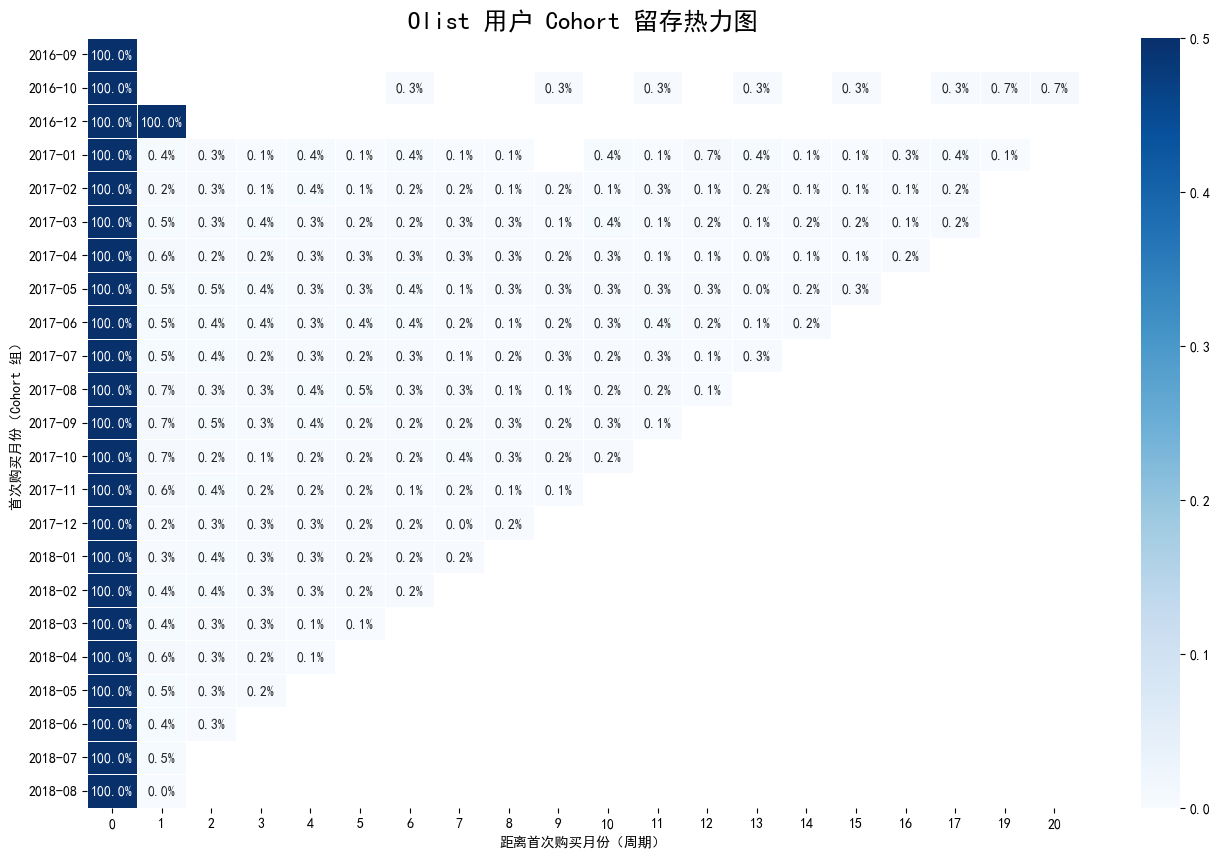

In [27]:
plt.figure(figsize=(16,10))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    vmin=0, vmax=0.5,
    linewidths=0.5
)
plt.title('Olist 用户 Cohort 留存热力图', fontsize=18)
plt.xlabel('距离首次购买月份（周期）')
plt.ylabel('首次购买月份（Cohort 组）')
plt.savefig('../visualizations/cohort_retention_heatmap.png', dpi=300)
plt.show()

### Cohort分析逻辑

1. 首先找到每位用户第一次购买的时间
2. 按照第一次购买的月份进行分组
3. 计算当前购买月份与第一次购买月份的周期
4. 计算每一组后续月份有多少人会再次购买
5. 计算对应留存率
6. 绘制热力图，实现可视化

---



### 核心结论

1. 用户整体留存率偏低，次月留存率普遍在 0.2%-0.8% 之间，平台用户首次购买后，绝大多数在次月不再复购，用户粘性较弱，生命周期价值（LTV）有限。

2. 留存随时间快速衰减，3个月后基本无有效留存，说明平台缺乏留住有效客户的召回与复购机制。

3. 不同 Cohort 组留存差异明显，早期用户质量更高，反映出后期拉新质量下降，新客户体验较差，导致不止留存率低，甚至根本没有新客户，濒临倒闭。

## 关键发现

1. 平台复购依赖度极低，增长主要靠新客，而非老客贡献。

2. 用户流失**集中发生在首月之后**，是最关键的流失节点。

3. 几乎没有“长期忠实用户”，用户生命周期极短。

4. 高留存组普遍集中在平台早期，说明**早期运营 / 商品 / 活动更能留住用户**。

# 运营建议

1. **重点抓"首月后流失"，建立30天召回体系**：
   对首次购买后30天未复购用户，推送复购券、专属折扣、个性化商品推荐
   设计"第二单优惠"满减返现等激励，强制提升次月留存

2. **针对高留存 Cohort 组复盘成功经验**：
   分析2016-2017高留存月份的商品结构、活动力度、物流体验等
   把成功策略复制到后期拉新，提升新客留存基线

3. **优化新客首单体验，提高长期留存潜力**：
   加强首单商品质量、物流时效、售后体验
   新客首单引导加入会员、领取复购券，锁定后续消费

4. **建立用户生命周期自动化触达**：
   7天未复购 → 温和提醒
   30天未复购 → 强利益刺激（优惠券）
   60天未复购 → 流失预警，专属挽回政策

5. **结合RFM做精细化运营**：
   对高价值但低留存用户重点挽回
   对高频但低消费用户提升客单价
   对低频低价值用户低成本唤醒即可